# Proyecto Final - KPIs

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery
from dotenv import load_dotenv

In [2]:
load_dotenv()

PROJECT_ID = os.getenv("ID_PROYECTO")

print("Proyecto:", PROJECT_ID)

Proyecto: proyectofinalg2


In [3]:
client = bigquery.Client(project=PROJECT_ID)

print("Conexión a BigQuery exitosa")

Conexión a BigQuery exitosa


In [4]:
def query_bq(sql):
    return client.query(sql).to_dataframe()

# KPI 1: Ventas Totales

In [5]:
sql_ventas_totales = """
SELECT
    SUM(total_venta) AS ventas_totales
FROM `proyectofinalg2.proyectofinalG2.fact_ventas`
"""

df_ventas_totales = query_bq(sql_ventas_totales)
df_ventas_totales

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,ventas_totales
0,17965.0


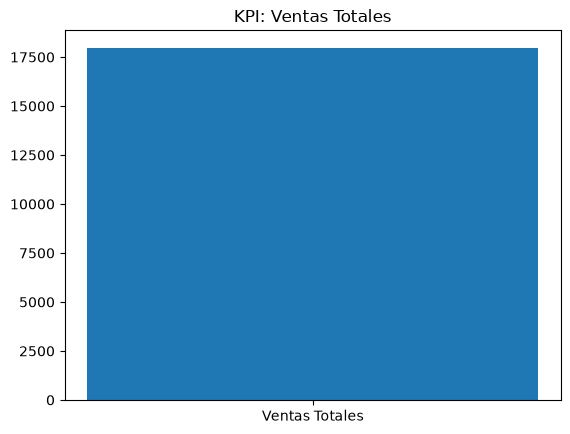

In [6]:
valor = df_ventas_totales["ventas_totales"][0]

plt.figure()
plt.bar(["Ventas Totales"], [valor])
plt.title("KPI: Ventas Totales")
plt.show()

## KPI 2 - Ticket Promedio

In [7]:
sql_ticket = """
SELECT
AVG(total_venta) AS ticket_promedio
FROM `proyectofinalg2.proyectofinalG2.fact_ventas`
"""

df_ticket = query_bq(sql_ticket)

df_ticket

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,ticket_promedio
0,3593.0


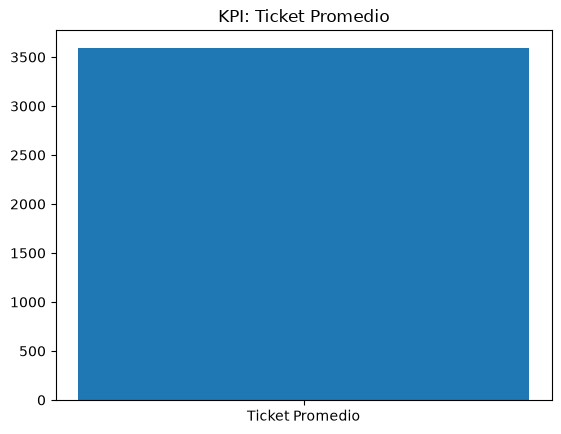

In [8]:
valor = df_ticket["ticket_promedio"][0]

plt.figure()
plt.bar(["Ticket Promedio"], [valor])
plt.title("KPI: Ticket Promedio")
plt.show()

## KPI 3 - Productos vendidos

In [9]:
sql_productos = """
SELECT
SUM(cantidad) AS productos_vendidos
FROM `proyectofinalg2.proyectofinalG2.fact_ventas`
"""

df_productos = query_bq(sql_productos)

df_productos

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,productos_vendidos
0,12


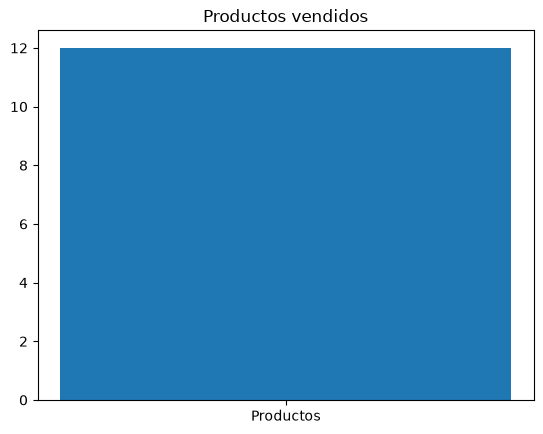

In [10]:
valor = df_productos["productos_vendidos"][0]

plt.figure()
plt.bar(["Productos"], [valor])
plt.title("Productos vendidos")
plt.show()

## KPI 4 - Ventas por canal

In [11]:
sql_canal = """
SELECT
c.canal_venta,
SUM(f.total_venta) AS ventas
FROM `proyectofinalg2.proyectofinalG2.fact_ventas` f
JOIN `proyectofinalg2.proyectofinalG2.dim_canal` c
ON f.canal_key=c.canal_key
GROUP BY c.canal_venta
ORDER BY ventas DESC
"""

df_canal = query_bq(sql_canal)

df_canal

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,canal_venta,ventas
0,Tienda,9890.0
1,E-commerce,6875.0
2,Whatsapp,1200.0


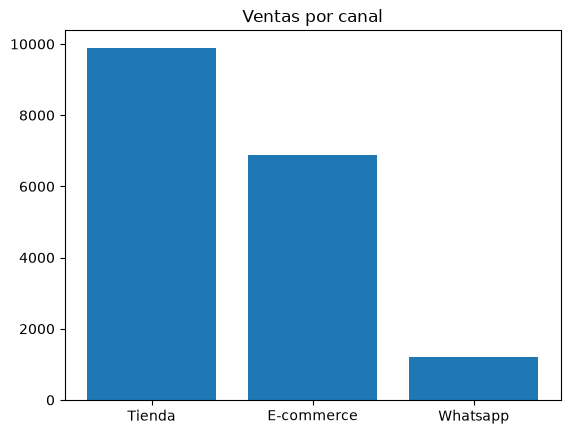

In [12]:
plt.figure()

plt.bar(
    df_canal["canal_venta"],
    df_canal["ventas"]
)

plt.title("Ventas por canal")

plt.show()

## KPI 5 - Ventas por sucursal

In [13]:
sql_sucursal = """
SELECT
s.nombre_sucursal,
SUM(f.total_venta) AS ventas
FROM `proyectofinalg2.proyectofinalG2.fact_ventas` f
JOIN `proyectofinalg2.proyectofinalG2.dim_sucursal` s
ON f.sucursal_key=s.sucursal_key
GROUP BY s.nombre_sucursal
ORDER BY ventas DESC
"""

df_sucursal = query_bq(sql_sucursal)

df_sucursal

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,nombre_sucursal,ventas
0,Sucursal Centro,9750.0
1,Sucursal Norte,7325.0
2,Sucursal Sur,890.0


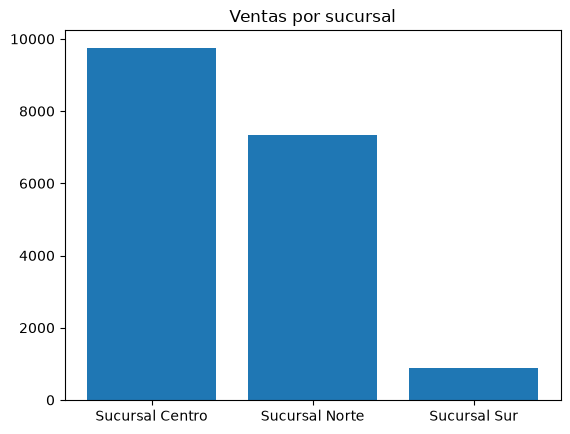

In [14]:
plt.figure()

plt.bar(
    df_sucursal["nombre_sucursal"],
    df_sucursal["ventas"]
)

plt.title("Ventas por sucursal")

plt.show()

## KPI 6 - Ventas por producto

In [15]:
sql_producto = """
SELECT
p.nombre_producto,
SUM(f.total_venta) AS ventas
FROM `proyectofinalg2.proyectofinalG2.fact_ventas` f
JOIN `proyectofinalg2.proyectofinalG2.dim_producto` p
ON f.producto_key=p.producto_key
GROUP BY p.nombre_producto
ORDER BY ventas DESC
"""

df_producto = query_bq(sql_producto)

df_producto

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,nombre_producto,ventas
0,Laptop Pro 14,9000.0
1,Monitor 27,7325.0
2,Teclado Mecanico,890.0
3,Mouse Inalambrico,750.0


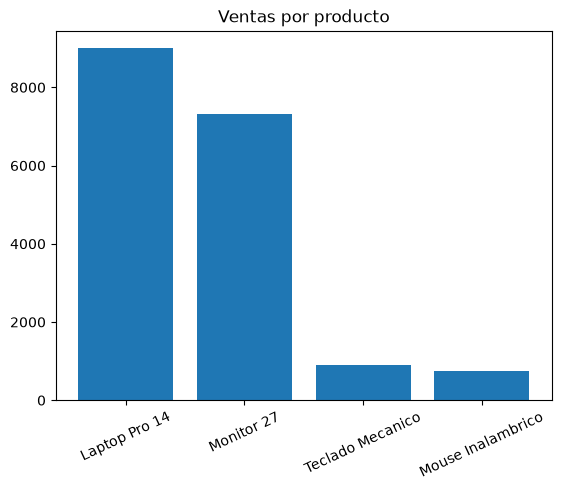

In [16]:
plt.figure()

plt.bar(
    df_producto["nombre_producto"],
    df_producto["ventas"]
)

plt.xticks(rotation=25)

plt.title("Ventas por producto")

plt.show()

## KPI 7 - Cantidad vendida por producto

In [17]:
sql_cantidad = """
SELECT
p.nombre_producto,
SUM(f.cantidad) AS cantidad
FROM `proyectofinalg2.proyectofinalG2.fact_ventas` f
JOIN `proyectofinalg2.proyectofinalG2.dim_producto` p
ON f.producto_key=p.producto_key
GROUP BY p.nombre_producto
ORDER BY cantidad DESC
"""

df_cantidad = query_bq(sql_cantidad)

df_cantidad

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,nombre_producto,cantidad
0,Monitor 27,6
1,Mouse Inalambrico,3
2,Laptop Pro 14,2
3,Teclado Mecanico,1


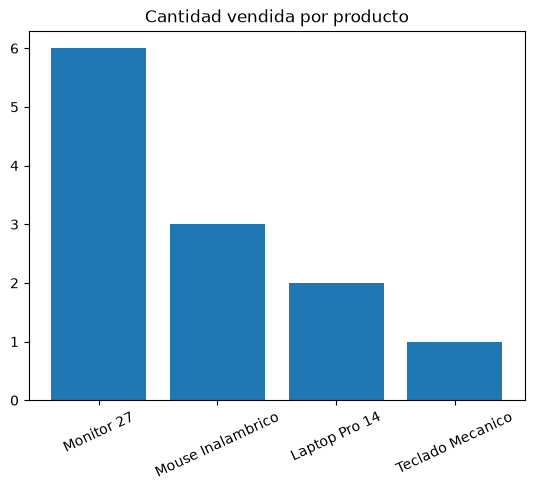

In [18]:
plt.figure()

plt.bar(
    df_cantidad["nombre_producto"],
    df_cantidad["cantidad"]
)

plt.xticks(rotation=25)

plt.title("Cantidad vendida por producto")

plt.show()

## KPI 8 - Ventas por segmento

In [19]:
sql_segmento = """
SELECT
c.segmento_cliente,
SUM(f.total_venta) AS ventas
FROM `proyectofinalg2.proyectofinalG2.fact_ventas` f
JOIN `proyectofinalg2.proyectofinalG2.dim_cliente` c
ON f.cliente_key=c.cliente_key
GROUP BY c.segmento_cliente
ORDER BY ventas DESC
"""

df_segmento = query_bq(sql_segmento)

df_segmento

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,segmento_cliente,ventas
0,Premium,9890.0
1,No disponible,6125.0
2,Frecuente,1200.0
3,Nuevo,750.0


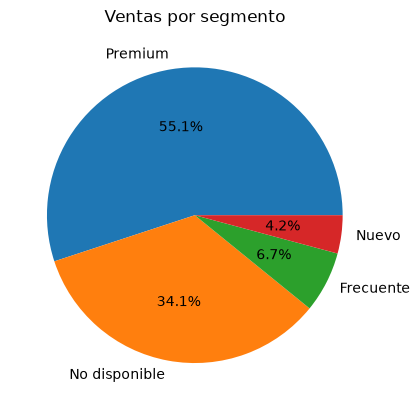

In [20]:
plt.figure()

plt.pie(
    df_segmento["ventas"],
    labels=df_segmento["segmento_cliente"],
    autopct="%1.1f%%"
)

plt.title("Ventas por segmento")

plt.show()

## KPI 9 - Ventas por día

In [21]:
sql_dia = """
SELECT
t.fecha,
SUM(f.total_venta) AS ventas
FROM `proyectofinalg2.proyectofinalG2.fact_ventas` f
JOIN `proyectofinalg2.proyectofinalG2.dim_tiempo` t
ON f.fecha_key=t.fecha_key
GROUP BY t.fecha
ORDER BY t.fecha
"""

df_dia = query_bq(sql_dia)

df_dia

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,fecha,ventas
0,2026-07-01,10200.0
1,2026-07-02,1640.0
2,2026-07-03,6125.0


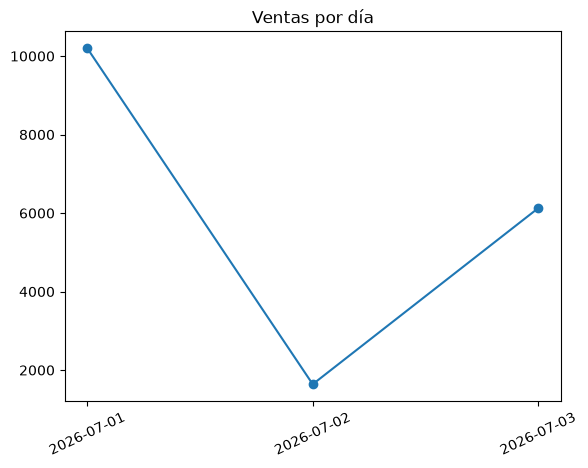

In [22]:
plt.figure()

plt.plot(
    df_dia["fecha"],
    df_dia["ventas"],
    marker="o"
)

plt.title("Ventas por día")

plt.xticks(rotation=25)

plt.show()

## KPI 10 - Total de descuentos

In [23]:
sql_descuento = """
SELECT
SUM(descuento) AS descuento_total
FROM `proyectofinalg2.proyectofinalG2.fact_ventas`
"""

df_descuento = query_bq(sql_descuento)

df_descuento

c:\Users\lucym\miniconda3\envs\bigquery_lab\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,descuento_total
0,175.0


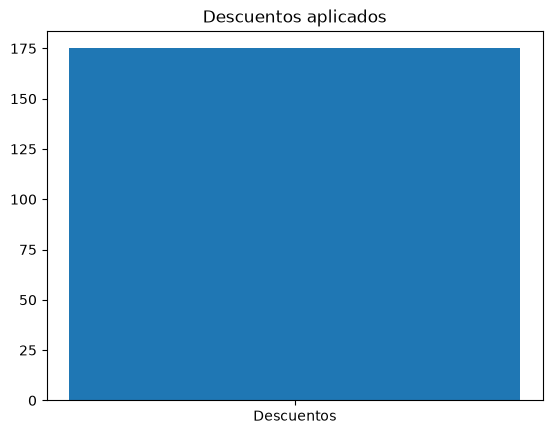

In [24]:
valor = df_descuento["descuento_total"][0]

plt.figure()

plt.bar(
    ["Descuentos"],
    [valor]
)

plt.title("Descuentos aplicados")

plt.show()